Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/interim/cleaned_day2.csv")

print(df.shape)
df.head()

(5710, 22)


,Accident_ID,Accident_Date,Accident_Time,Report_Timestamp,District,Road_Type,Weather_Condition,Surface_Condition,Light_Condition,Traffic_Density,Vehicle_Type,Driver_Age,Driver_Gender,Alcohol_Involved,Vehicle_Speed_kmph,Helmet_Used,Seatbelt_Used,Cause_Category,Accident_Severity,Casualties_Count,Injury_Type,Emergency_Response_Time_Min
0,Ker_Acc_100000,2023-04-25,00:47:00,2023-04-25 02:02:00,Kozhikode,Bridge,Clear,Dry,Night,Medium,Truck,23,Male,No,90,Not Applicable,No,Drunk Driving,Minor,1,No Injury,6.0
1,Ker_Acc_100031,2024-06-01,19:01:00,2024-06-01 21:29:00,Alappuzha,Urban Road,Clear,Dry,Night,Medium,Motorcycle,32,Female,No,58,Yes,Not Applicable,Mechanical Failure,Minor,1,No Injury,13.0
2,Ker_Acc_100002,2025-04-05,05:44:00,2025-04-05 07:37:00,Kannur,Rural Road,Clear,Wet,Night,Low,Car,24,Female,Yes,54,Not Applicable,Yes,Mechanical Failure,Serious,1,Minor Injury,13.0
3,Ker_Acc_100003,2023-09-28,01:46:00,2023-09-28 03:48:00,Malappuram,Junction,Clear,Dry,Night,Medium,Car,53,Female,No,32,Not Applicable,Yes,Weather Conditions,Minor,2,Minor Injury,25.0
4,Ker_Acc_100004,2023-07-16,22:04:00,2023-07-16 22:20:00,Malappuram,Highway,Fog,Dry,Night,Medium,Car,32,Female,No,112,Not Applicable,Yes,Weather Conditions,Serious,2,Major Injury,22.0


Section 1: Separate Column Types

In [3]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

cat_cols = df.select_dtypes(include=['object','str']).columns.tolist()

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 4
Categorical: 18


Section 2: Univariate Analysis (Numerical)

In [4]:
num_analysis = [
    'Driver_Age',
    'Vehicle_Speed_kmph',
    'Casualties_Count',
    'Emergency_Response_Time_Min'
]

Histogram + KDE

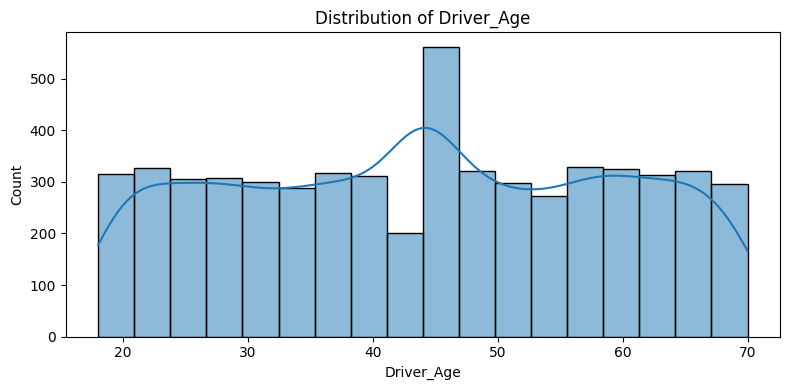

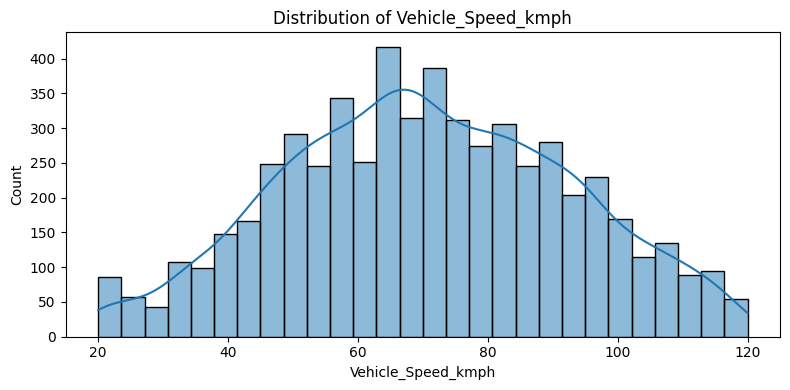

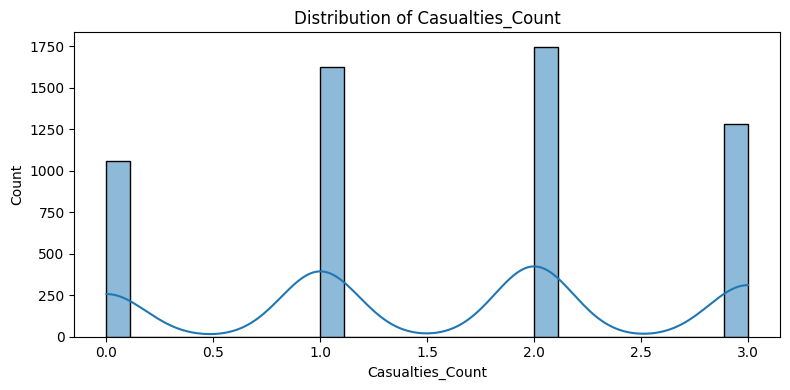

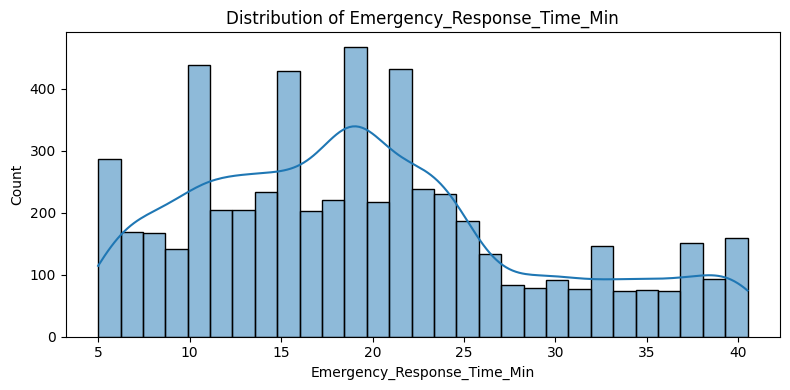

In [5]:
for col in num_analysis:

    plt.figure(figsize=(8,4))
    sns.histplot(df[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.savefig(f"../reports/figures/{col}_hist.png")

    plt.show()

Boxplots

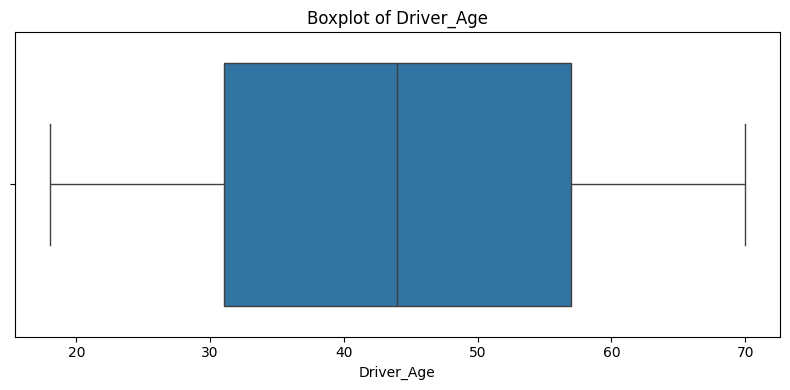

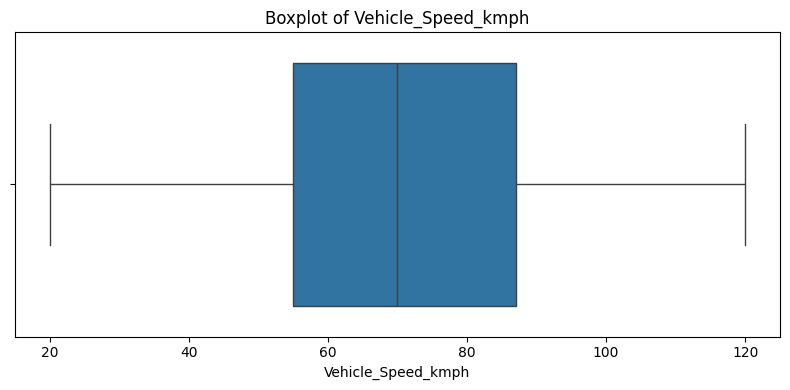

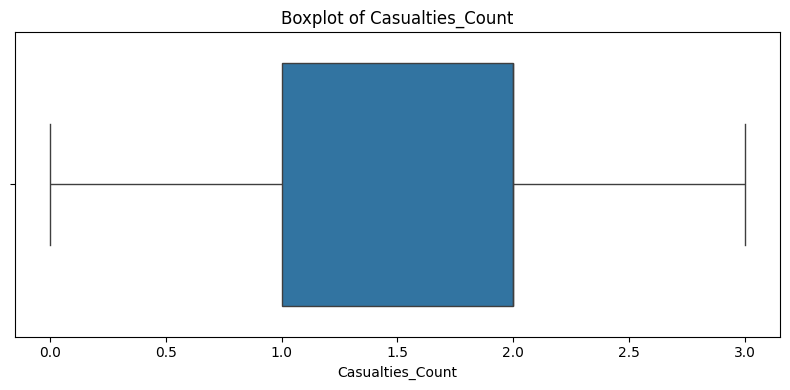

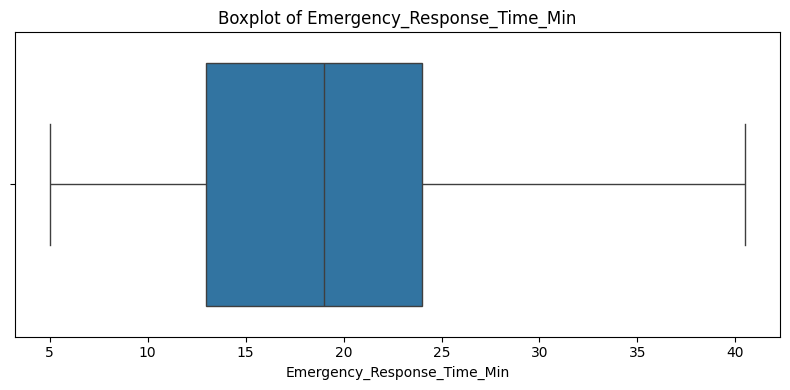

In [6]:
for col in num_analysis:

    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.savefig(f"../reports/figures/{col}_box.png")

    plt.show()

In [7]:
df[num_analysis].describe().T

,count,mean,std,min,25%,50%,75%,max
Driver_Age,5710.0,43.986340,15.021739,18.0,31.0,44.0,57.0,70.0
Vehicle_Speed_kmph,5710.0,70.618214,22.037865,20.0,55.0,70.0,87.0,120.0
Casualties_Count,5710.0,1.569177,1.031996,0.0,1.0,2.0,2.0,3.0
Emergency_Response_Time_Min,5710.0,19.657005,9.153160,5.0,13.0,19.0,24.0,40.5


Section 3: Univariate Analysis (Categorical)

In [8]:
cat_analysis = [
    'Accident_Severity',
    'Weather_Condition',
    'Vehicle_Type',
    'Road_Type',
    'Driver_Gender'
]

Frequency Tables

In [9]:
for col in cat_analysis:

    display(df[col].value_counts())

Accident_Severity
Minor      3369
Serious    2181
Fatal       160
Name: count, dtype: int64

Weather_Condition
Clear    3263
Rain     1637
Fog       429
Storm     381
Name: count, dtype: int64

Vehicle_Type
Motorcycle       2100
Car              1713
Auto Rickshaw     791
Truck             665
Bus               441
Name: count, dtype: int64

Road_Type
Urban Road    2225
Highway       1301
Rural Road    1081
Junction       831
Bridge         272
Name: count, dtype: int64

Driver_Gender
Female    2993
Male      2717
Name: count, dtype: int64

Bar Charts

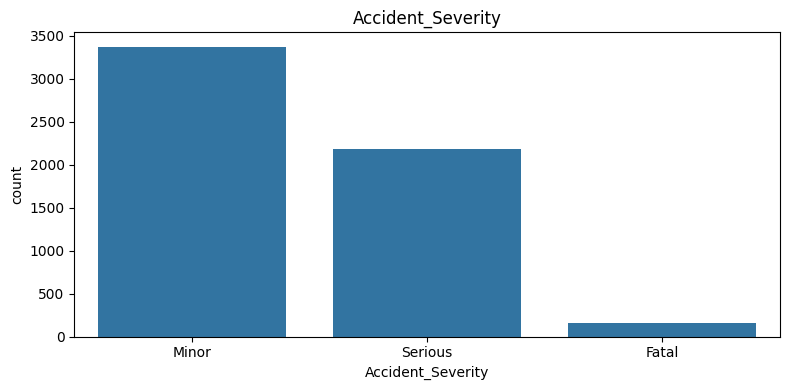

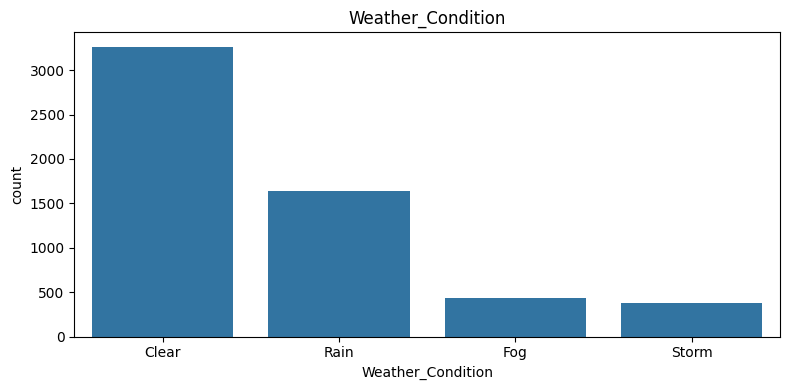

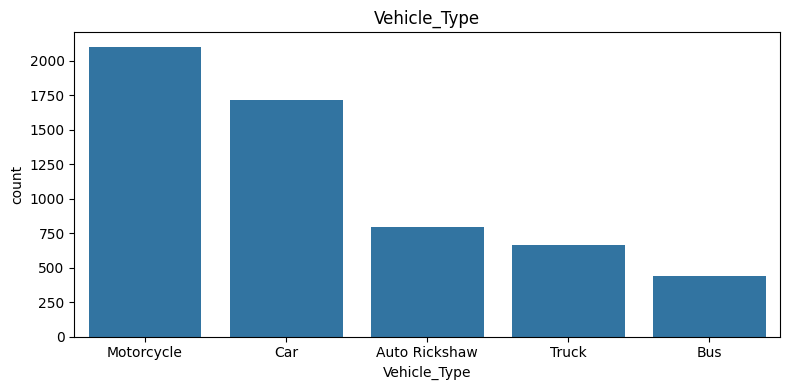

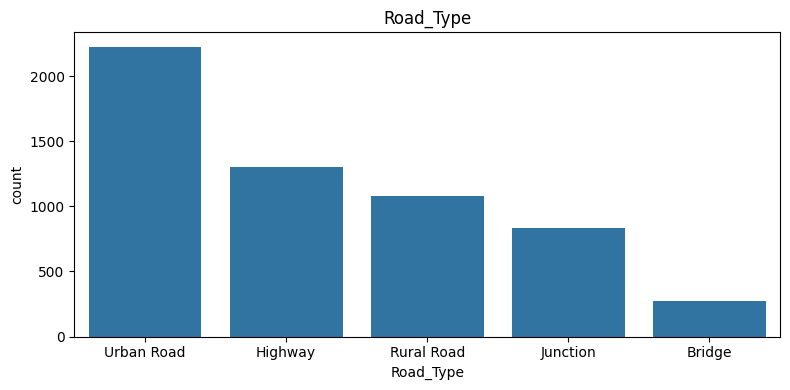

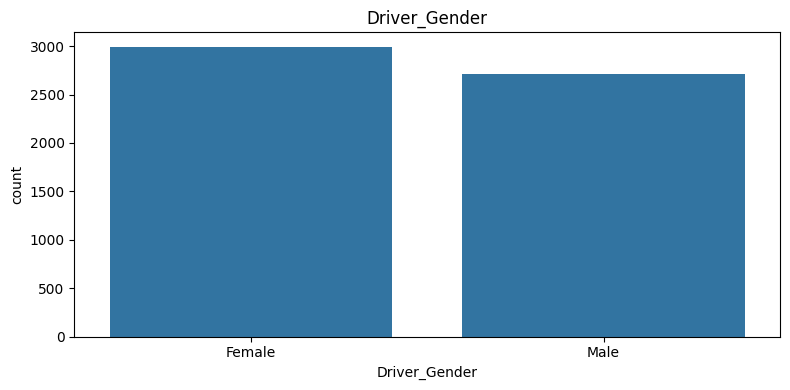

In [10]:
for col in cat_analysis:

    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(col)
    plt.tight_layout()
    plt.savefig(f"../reports/figures/{col}_countplot.png")
    plt.show()

Section 4: Correlation Analysis

In [11]:
corr = df[num_cols].corr()
corr

,Driver_Age,Vehicle_Speed_kmph,Casualties_Count,Emergency_Response_Time_Min
Driver_Age,1.000000,-0.001555,0.006931,0.000907
Vehicle_Speed_kmph,-0.001555,1.000000,0.189825,0.195982
Casualties_Count,0.006931,0.189825,1.000000,0.343003
Emergency_Response_Time_Min,0.000907,0.195982,0.343003,1.000000


Heatmap

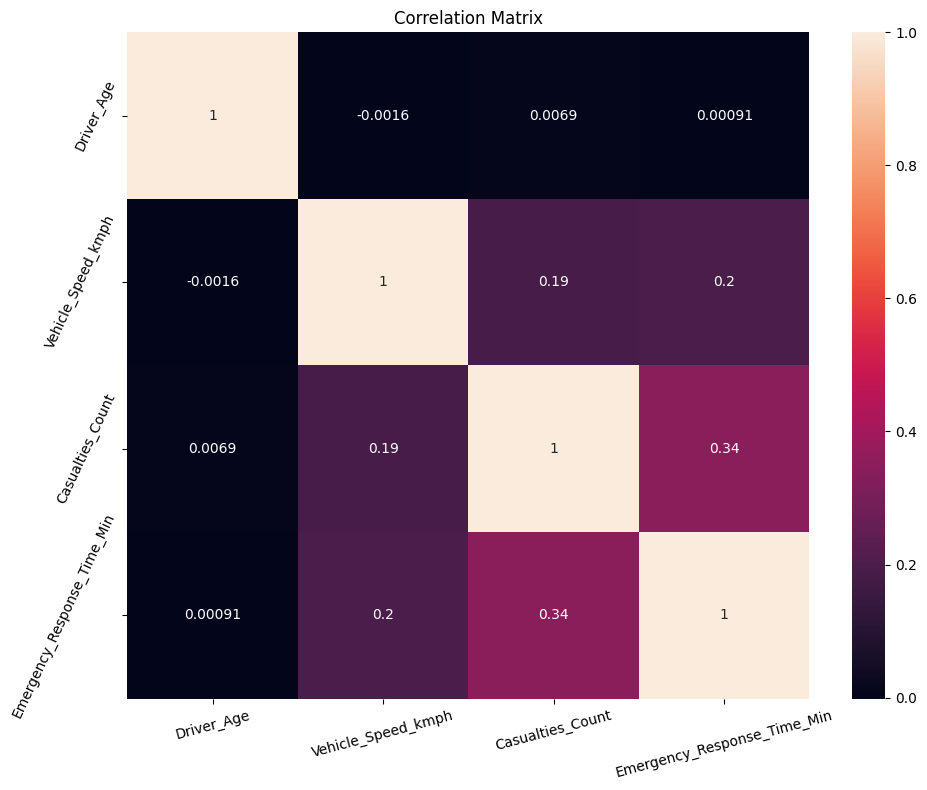

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.xticks(rotation=15)
plt.yticks(rotation=65)
plt.tight_layout()
plt.savefig("../reports/figures/correlation_heatmap.png")
plt.show()

Section 5: Numeric vs Numeric

Speed vs Casualties

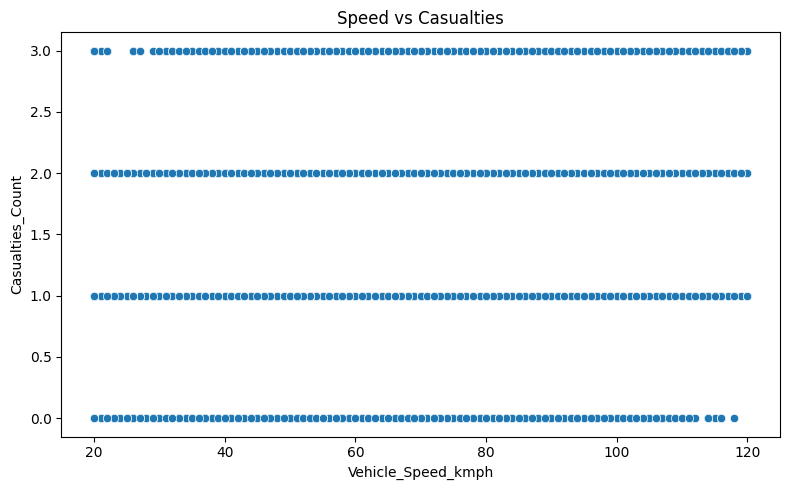

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Vehicle_Speed_kmph', y='Casualties_Count')
plt.title("Speed vs Casualties")
plt.tight_layout()
plt.savefig("../reports/figures/speed_vs_casualties.png")
plt.show()

Age vs Speed

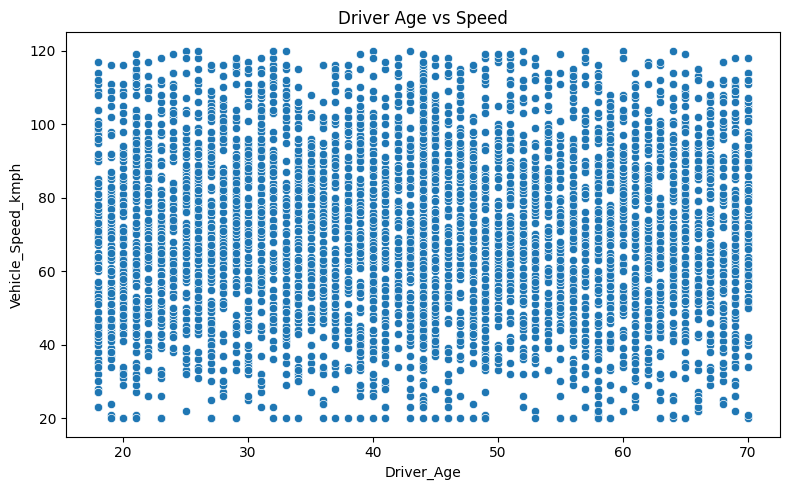

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Driver_Age', y='Vehicle_Speed_kmph')
plt.title("Driver Age vs Speed")
plt.tight_layout()
plt.savefig("../reports/figures/age_vs_speed.png")
plt.show()

Section 6: Numeric vs Categorical

Speed by Severity

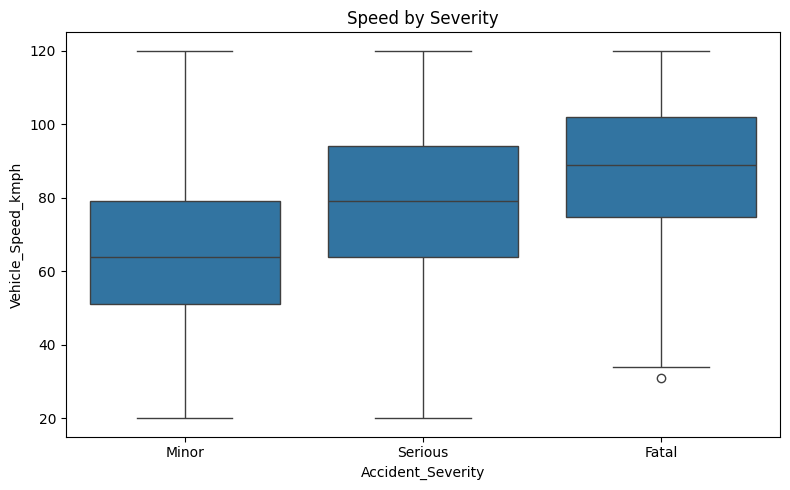

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Accident_Severity', y='Vehicle_Speed_kmph')
plt.title("Speed by Severity")
plt.tight_layout()
plt.savefig("../reports/figures/speed_by_severity.png")
plt.show()

Response Time by Road Type

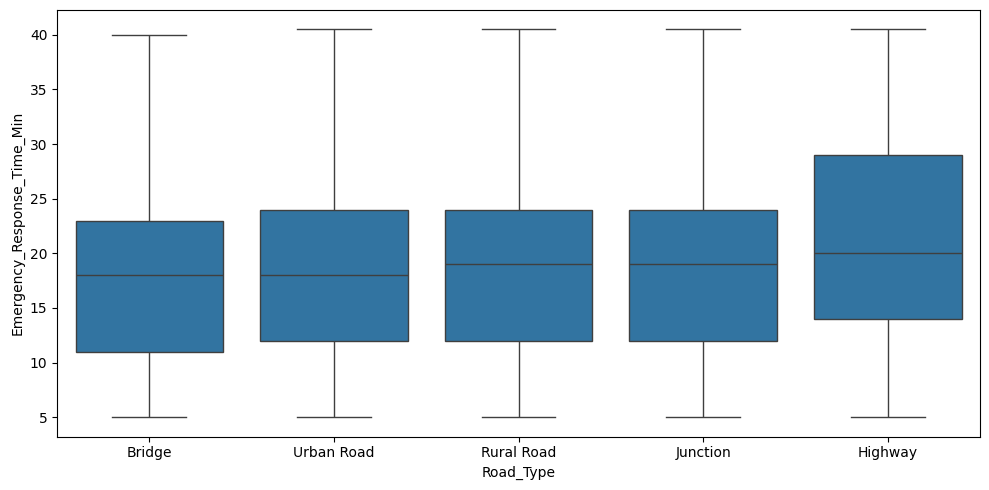

In [16]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Road_Type', y='Emergency_Response_Time_Min')
plt.tight_layout()
plt.savefig("../reports/figures/response_by_road.png")
plt.show()

Section 7: Categorical vs Categorical

Severity vs Weather

In [17]:
severity_weather = pd.crosstab(
    df['Weather_Condition'],
    df['Accident_Severity']
)

severity_weather

Accident_Severity,Fatal,Minor,Serious
Weather_Condition,,,
Clear,32,2387,844
Fog,14,217,198
Rain,100,560,977
Storm,14,205,162


Visualization

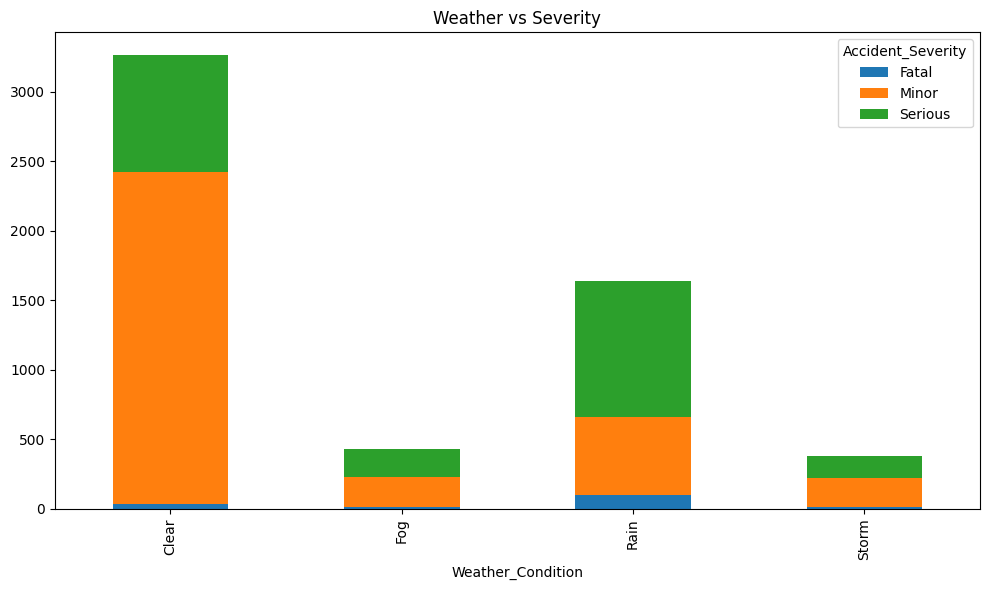

In [18]:
severity_weather.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Weather vs Severity")
plt.tight_layout()
plt.savefig("../reports/figures/weather_severity.png")
plt.show()

Section 8: Segment Analysis

District Analysis

In [19]:
district_accidents = (df['District'].value_counts().head(10))

district_accidents

District
Malappuram            683
Ernakulam             420
Thrissur              417
Alappuzha             400
Pathanamthitta        395
Thiruvananthapuram    394
Idukki                394
Kollam                382
Kannur                380
Palakkad              377
Name: count, dtype: int64

Visualization

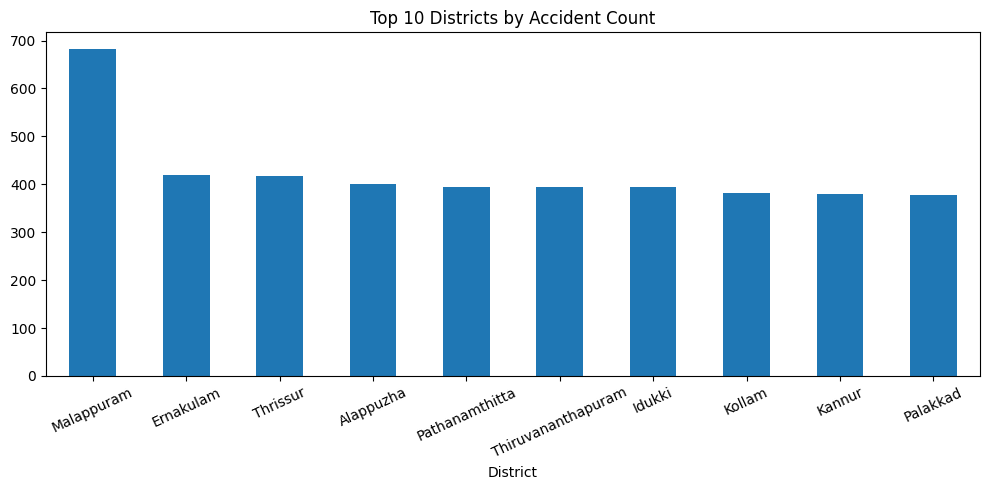

In [32]:
plt.figure(figsize=(10,5))

district_accidents.plot(kind='bar')
plt.title("Top 10 Districts by Accident Count")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("../reports/figures/top_districts.png")
plt.show()

Vehicle Type Analysis

In [21]:
vehicle_severity = pd.crosstab(
    df['Vehicle_Type'],
    df['Accident_Severity']
)

vehicle_severity

Accident_Severity,Fatal,Minor,Serious
Vehicle_Type,,,
Auto Rickshaw,14,528,249
Bus,16,310,115
Car,48,1160,505
Motorcycle,70,913,1117
Truck,12,458,195


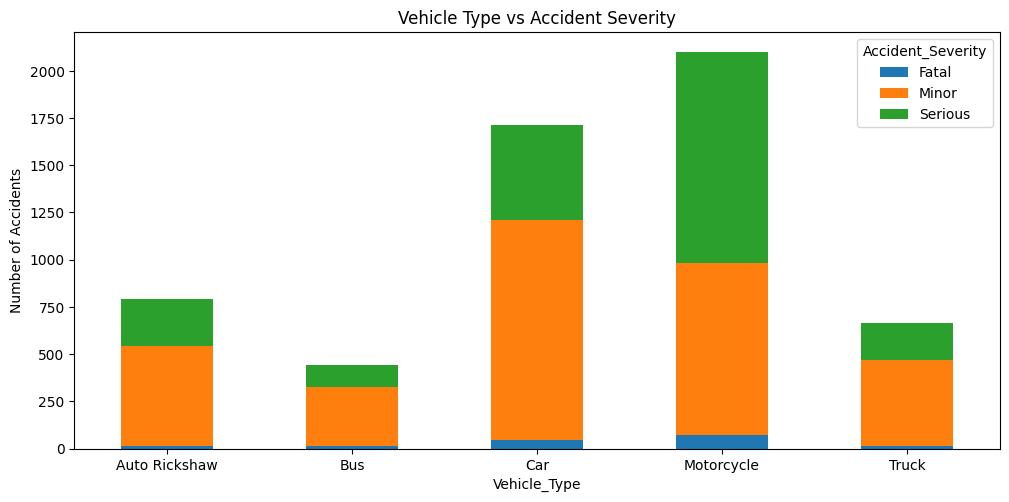

In [22]:
vehicle_severity.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Vehicle Type vs Accident Severity")
plt.tight_layout()
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0)
plt.savefig("../reports/figures/vehicle_severity.png")
plt.show()

Section 9: Helmet & Seatbelt Impact

In [23]:
helmet_df = df[df['Helmet_Used'] != "Not Applicable"]

helmet = pd.crosstab(
    helmet_df['Helmet_Used'],
    helmet_df['Accident_Severity']
)

helmet

Accident_Severity,Fatal,Minor,Serious
Helmet_Used,,,
No,10,144,212
Yes,55,621,797


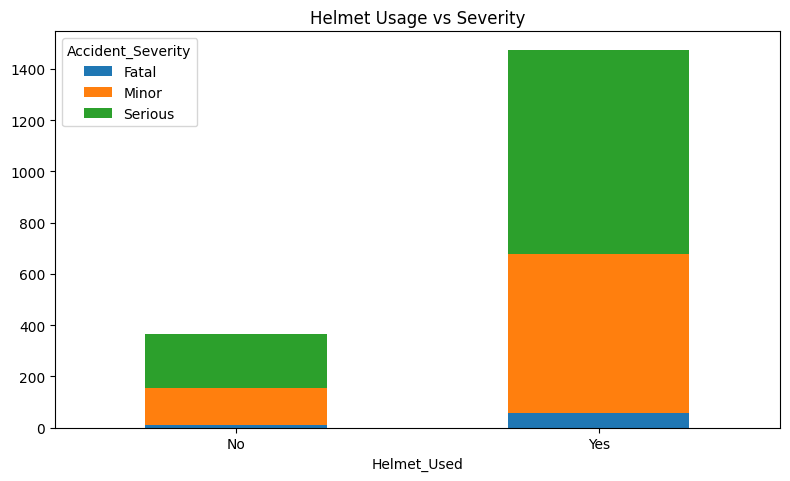

In [24]:
helmet.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Helmet Usage vs Severity")
plt.tight_layout()
plt.xticks(rotation=0)
plt.savefig("../reports/figures/helmet_severity.png")
plt.show()

Seatbelt Usage

In [25]:
seatbelt_df = df[df['Seatbelt_Used'] != "Not Applicable"]

seatbelt = pd.crosstab(
    seatbelt_df['Seatbelt_Used'],
    seatbelt_df['Accident_Severity']
)

seatbelt

Accident_Severity,Fatal,Minor,Serious
Seatbelt_Used,,,
No,9,319,118
Yes,65,1631,696


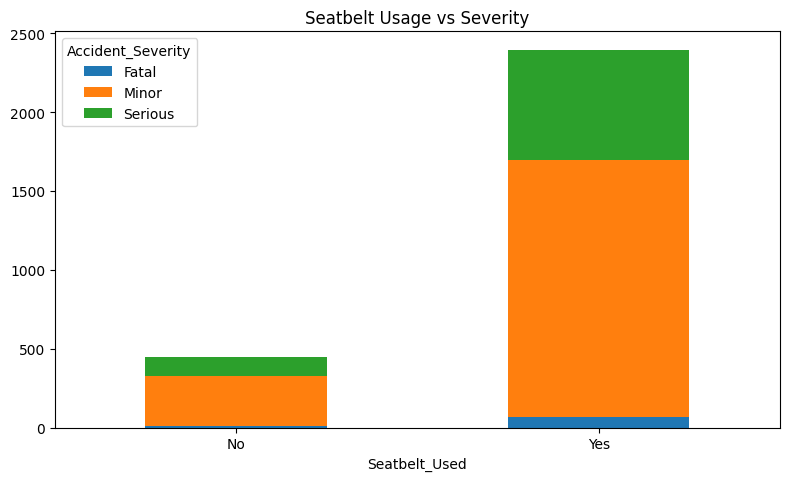

In [26]:
seatbelt.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Seatbelt Usage vs Severity")
plt.tight_layout()
plt.xticks(rotation=0)
plt.savefig("../reports/figures/seatbelt_severity.png")
plt.show()

Findings
1. Most accidents involve Motorcycle vehicle type.
2. Highest accident frequency occurs in Malappuram district.
3. Severe accidents are associated with higher speeds.
4. Helmet usage appears associated with higher severity.
5. Certain weather conditions show higher fatality proportions.
6. Response time varies across road types.
7. Casualties doesnt change much as speed increases.